# Week1복습과제_김태희
**유런 · 딥러닝 파이토치 교과서 · 6.1.5 ResNet (인쇄 p.312–340)**

코드 흐름: 잔차 연결 → 데이터 준비 → BasicBlock/Bottleneck → ResNet → 학습·검증 → 최적 모델 복원 → 테스트 예측.

이 노트북은 교재의 구현을 바탕으로 설명 주석과 오류 방지 처리를 추가한 코드 리뷰입니다.
기존 노트북의 `forward` 코드는 2절에 보존했습니다. 

**실행 설정:** 저장된 출력은 로컬 CPU에서 교재 공식 이미지 데이터를 사용해 실행한 결과입니다.
전체 학습 흐름을 확인하기 위해 입력 64×64, 2 epochs를 사용합니다. 교재의 224×224, 10 epochs 결과와 직접 비교할 수 없습니다.
아래 `FULL_RUN=True`로 바꾸면 교재 크기와 epoch 수로 실행합니다. 합성 데이터나 교재 출력값을 실행 결과로 대신하지 않습니다.

**제출 정보:** 파일/PR 제목 `Week1복습과제_김태희`, 라벨 `복습과제`, 안내된 브랜치 `Week_1`.
안내문에 `Week1`도 함께 적혀 있으므로 PR의 실제 대상 브랜치는 저장소에서 확인해야 합니다.


## 1. ResNet 핵심 정리 · p.312–317

깊은 일반 신경망은 최적화가 어려워져 훈련 오차가 오히려 커질 수 있습니다. ResNet은 블록이 전체 변환 H(x) 대신 잔차 F(x)=H(x)−x를 학습하도록 합니다.
출력은 `ReLU(F(x)+x)`이며, 두 경로의 크기가 다르면 `ReLU(F(x)+W_s(x))`가 됩니다.
항등 경로는 역전파에서 기울기가 전달되는 직접 경로를 제공합니다. 모든 조건에서 기울기 소실을 없애거나 성능 향상을 보장한다는 뜻은 아닙니다.

| 구성 | 잔차 경로 | 사용 모델 | 출력 채널 |
|---|---|---|---|
| BasicBlock | 3×3 → 3×3 | ResNet18/34 | channels |
| Bottleneck | 1×1 → 3×3 → 1×1 | ResNet50/101/152 | channels×4 |

병목 블록은 3×3 연산을 좁은 채널에서 수행합니다. 파라미터 절감은 **같은 입출력 폭에서의 블록 비교**에 대한 설명이며, ResNet50 전체가 ResNet34보다 항상 작다는 뜻이 아닙니다.


In [1]:
import copy
import csv
import json
import random
import time
import urllib.request
import zipfile
from collections import namedtuple, Counter
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms, models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.set_num_threads(min(4, torch.get_num_threads()))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
FULL_RUN = False
SIZE, EPOCHS = (224, 10) if FULL_RUN else (64, 2)
BATCH_SIZE = 32
LR = 1e-7  # 교재 설정 유지. 짧은 학습에서 큰 성능 향상을 기대하기 어렵다.
MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
print('PyTorch:', torch.__version__, '| torchvision:', torchvision.__version__)
print('device:', device, '| size:', SIZE, '| epochs:', EPOCHS, '| lr:', LR)


PyTorch: 2.14.0+cpu | torchvision: 0.29.0+cpu
device: cpu | size: 64 | epochs: 2 | lr: 1e-07


## 2. 기존 forward 코드 리뷰 · p.315, 323

`i = x`는 잔차 연결용 입력을 보관합니다. `conv → BN → ReLU → conv → BN`이 F(x)를 계산하고,
필요할 때 `downsample`이 입력의 채널 수와 공간 크기를 맞춥니다. **두 경로의 shape가 같아야 더할 수 있습니다.**
기존 함수는 아래에 그대로 보존합니다. 함수 정의만으로는 모델이 완성되지 않으므로 뒤에서 해당 속성을 가진 클래스를 구현합니다.


In [2]:
def forward(self, x):
    i = x
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)
    x = self.conv2(x)
    x = self.bn2(x)

    if self.downsample is not None:
        i = self.downsample(i)

    x += i
    x = self.relu(x)
    return x


## 3. 데이터 준비와 전처리 · 코드 6-65–6-72, p.318–322

공식 저장소의 `dogs-vs-cats.zip`을 내려받습니다. 압축 파일은 캐시하고, 손상 이미지를 제외한 뒤
교재처럼 시드 42로 섞어 훈련 400개 / 검증 나머지 / 테스트 10개로 분리합니다.
분리 이후 훈련 데이터에만 무작위 자르기·좌우 반전을 적용합니다. 검증과 테스트에는 결정적인 변환을 적용합니다.

파일 경로는 `Path`로 처리하고, 클래스 폴더명을 레이블로 사용합니다. 파일명을 점이나 `/`로 자르는 방식보다 운영체제와 파일명 변화에 안전합니다.
RGB 변환으로 흑백 이미지의 채널 수 문제도 막습니다. ImageNet 정규화는 입력 스케일을 맞추며, 이것만으로 사전학습이 적용되지는 않습니다.


In [3]:
DATA_ROOT = Path('data/week1')
DATA_ROOT.mkdir(parents=True, exist_ok=True)
archive = DATA_ROOT / 'dogs-vs-cats.zip'
DATA_URL = 'https://raw.githubusercontent.com/gilbutITbook/080289/main/chap06/data/dogs-vs-cats.zip'
if not archive.exists():
    urllib.request.urlretrieve(DATA_URL, archive)
# ZIP 경로가 데이터 폴더 밖을 가리키지 않는지 확인한 뒤 해제한다.
with zipfile.ZipFile(archive) as z:
    root = DATA_ROOT.resolve()
    for name in z.namelist():
        if not (root / name).resolve().is_relative_to(root):
            raise ValueError('안전하지 않은 ZIP 경로')
    z.extractall(root)

samples, invalid = [], []
for path in sorted(DATA_ROOT.rglob('*')):
    label_name = path.parent.name.lower()
    if path.suffix.lower() not in {'.jpg', '.jpeg', '.png'} or label_name not in {'cat', 'dog'}:
        continue
    try:
        with Image.open(path) as im:
            im.convert('RGB').load()  # 실제 디코딩까지 수행해 손상 파일 검사
        samples.append((path, {'cat': 0, 'dog': 1}[label_name]))
    except (OSError, ValueError):
        invalid.append(str(path))
random.Random(SEED).shuffle(samples)
assert len(samples) > 410, '훈련·검증·테스트를 만들 데이터가 부족합니다.'
train_samples, val_samples, test_samples = samples[:400], samples[400:-10], samples[-10:]
assert not (set(p for p, _ in train_samples) & set(p for p, _ in val_samples))
assert not (set(p for p, _ in train_samples + val_samples) & set(p for p, _ in test_samples))
print('손상 파일 수:', len(invalid))
for name, split in [('train', train_samples), ('valid', val_samples), ('test', test_samples)]:
    print(name, len(split), '| label counts:', dict(sorted(Counter(y for _, y in split).items())))


손상 파일 수: 0
train 400 | label counts: {0: 199, 1: 201}
valid 92 | label counts: {0: 45, 1: 47}
test 10 | label counts: {0: 7, 1: 3}


배치: (32, 3, 64, 64) | label dtype: torch.int64
레이블 앞 10개: [0, 1, 1, 1, 0, 1, 0, 0, 0, 1]


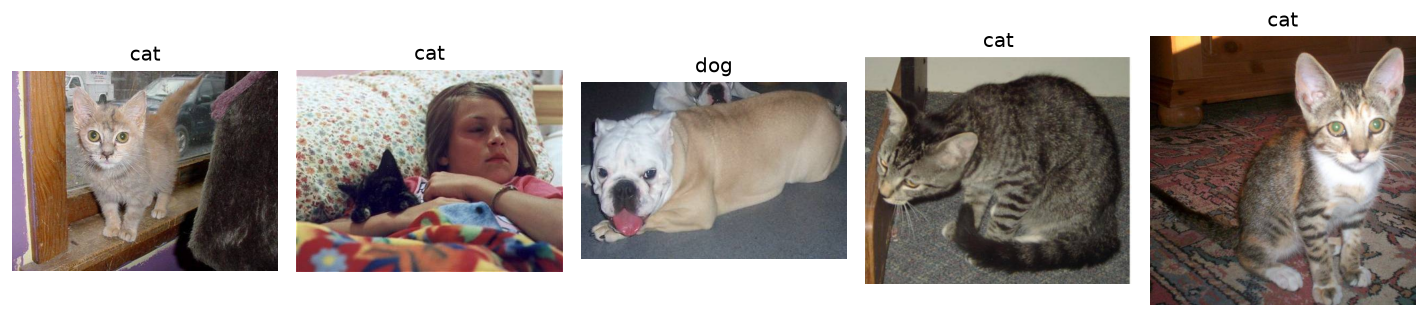

In [4]:
class ImageTransform:
    def __init__(self, size, mean, std):
        self.transforms = {
            'train': transforms.Compose([
                transforms.RandomResizedCrop(size, scale=(0.5, 1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(mean, std),
            ]),
            'val': transforms.Compose([
                transforms.Resize(round(size * 256 / 224)),
                transforms.CenterCrop(size),
                transforms.ToTensor(),
                transforms.Normalize(mean, std),
            ]),
        }
    def __call__(self, image, phase):
        return self.transforms[phase](image)

class DogsVsCatsDataset(Dataset):
    def __init__(self, samples, transform, phase):
        self.samples, self.transform, self.phase = samples, transform, phase
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, index):
        path, label = self.samples[index]
        with Image.open(path) as image:
            x = self.transform(image.convert('RGB'), self.phase)
        return x, label

transform = ImageTransform(SIZE, MEAN, STD)
train_dataset = DogsVsCatsDataset(train_samples, transform, 'train')
val_dataset = DogsVsCatsDataset(val_samples, transform, 'val')
test_dataset = DogsVsCatsDataset(test_samples, transform, 'val')
generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, generator=generator)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
x, y = next(iter(train_loader))
print('배치:', tuple(x.shape), '| label dtype:', y.dtype)
print('레이블 앞 10개:', y[:10].tolist())
assert x.shape[1:] == (3, SIZE, SIZE) and y.dtype == torch.int64

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for ax, (path, label) in zip(axes, train_samples[:5]):
    with Image.open(path) as im:
        ax.imshow(im.convert('RGB'))
    ax.set_title({0: 'cat', 1: 'dog'}[label])
    ax.axis('off')
plt.tight_layout()
plt.show()


## 4. 기본 블록과 병목 블록 · 코드 6-73–6-74, p.322–325

합성곱 뒤에 BN이 있으므로 `bias=False`로 중복되는 편향을 줄입니다.
`stride != 1` **또는** 입출력 채널이 다르면 1×1 합성곱을 shortcut에 사용합니다.
교재의 병목 블록처럼 stride는 첫 번째 1×1 합성곱에 둡니다. TorchVision 구현은 3×3에 두는 변형이므로 완전히 같은 계산이라고 보지 않습니다.


In [5]:
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_channels, channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.relu = nn.ReLU(inplace=False)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)
        self.downsample = None
        if stride != 1 or in_channels != channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, channels, 1, stride, bias=False),
                nn.BatchNorm2d(channels))
    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(identity)
        return self.relu(out + identity)  # 덧셈 후 활성화

class Bottleneck(nn.Module):
    expansion = 4
    def __init__(self, in_channels, channels, stride=1):
        super().__init__()
        out_channels = channels * self.expansion
        self.conv1 = nn.Conv2d(in_channels, channels, 1, stride, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)
        self.conv3 = nn.Conv2d(channels, out_channels, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=False)
        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels))
    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        if self.downsample is not None:
            identity = self.downsample(identity)
        return self.relu(out + identity)

with torch.no_grad():
    for block, cin, channels, stride in [
        (BasicBlock, 64, 64, 1), (BasicBlock, 64, 128, 2),
        (Bottleneck, 64, 64, 1), (Bottleneck, 256, 128, 2)]:
        b = block(cin, channels, stride).eval()
        out = b(torch.randn(2, cin, 16, 16))
        expected = (2, channels * block.expansion, 16 // stride, 16 // stride)
        assert tuple(out.shape) == expected
        print(block.__name__, 'stride=', stride, '->', tuple(out.shape))
# 잔차 경로를 0으로 만들면 양수 입력은 그대로 통과해야 한다.
b = BasicBlock(8, 8).eval()
nn.init.zeros_(b.bn2.weight)
positive_x = torch.rand(2, 8, 8, 8)
assert torch.allclose(b(positive_x), positive_x)
print('잔차가 0일 때 항등 연결 검증: PASS')


BasicBlock stride= 1 -> (2, 64, 16, 16)
BasicBlock stride= 2 -> (2, 128, 8, 8)
Bottleneck stride= 1 -> (2, 256, 16, 16)
Bottleneck stride= 2 -> (2, 512, 8, 8)
잔차가 0일 때 항등 연결 검증: PASS


## 5. ResNet 전체 구성 · 코드 6-75–6-81, p.325–333

`namedtuple`은 설정에 이름을 붙여 `block`, `n_blocks`, `channels`로 접근하게 합니다.
stem(7×7 conv, BN, ReLU, max-pool) → 4개 stage → 전역 평균 풀링 → 분류기를 연결합니다.
224 입력에서 stem 합성곱 후 112, max-pool 후 56, stage별 56→28→14→7이 됩니다.
`AdaptiveAvgPool2d(1)` 때문에 64 입력에서도 같은 분류기를 사용할 수 있습니다.

교재처럼 `(logits, features)`를 반환합니다. 손실에는 `logits`를 사용하고 중간 특징은 분석용으로 보존합니다.
직접 만든 모델은 **무작위 초기화**이며 사전학습 가중치를 사용하지 않습니다.


In [6]:
ResNetConfig = namedtuple('ResNetConfig', ['block', 'n_blocks', 'channels'])
configs = {
    18: ResNetConfig(BasicBlock, [2, 2, 2, 2], [64, 128, 256, 512]),
    34: ResNetConfig(BasicBlock, [3, 4, 6, 3], [64, 128, 256, 512]),
    50: ResNetConfig(Bottleneck, [3, 4, 6, 3], [64, 128, 256, 512]),
    101: ResNetConfig(Bottleneck, [3, 4, 23, 3], [64, 128, 256, 512]),
    152: ResNetConfig(Bottleneck, [3, 8, 36, 3], [64, 128, 256, 512]),
}

class ResNet(nn.Module):
    def __init__(self, config, output_dim=2, zero_init_residual=False):
        super().__init__()
        block, counts, channels = config
        assert len(counts) == len(channels) == 4
        self.in_channels = channels[0]
        self.conv1 = nn.Conv2d(3, self.in_channels, 7, 2, 3, bias=False)
        self.bn1 = nn.BatchNorm2d(self.in_channels)
        self.relu = nn.ReLU(inplace=False)
        self.maxpool = nn.MaxPool2d(3, 2, 1)
        self.layer1 = self.make_layer(block, counts[0], channels[0])
        self.layer2 = self.make_layer(block, counts[1], channels[1], 2)
        self.layer3 = self.make_layer(block, counts[2], channels[2], 2)
        self.layer4 = self.make_layer(block, counts[3], channels[3], 2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(self.in_channels, output_dim)
        if zero_init_residual:
            for module in self.modules():
                if isinstance(module, Bottleneck):
                    nn.init.zeros_(module.bn3.weight)
                elif isinstance(module, BasicBlock):
                    nn.init.zeros_(module.bn2.weight)
    def make_layer(self, block, count, channels, stride=1):
        layers = [block(self.in_channels, channels, stride)]
        self.in_channels = channels * block.expansion
        layers.extend(block(self.in_channels, channels) for _ in range(1, count))
        return nn.Sequential(*layers)
    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer4(self.layer3(self.layer2(self.layer1(x))))
        features = torch.flatten(self.avgpool(x), 1)
        return self.fc(features), features

torch.manual_seed(SEED)
model = ResNet(configs[50], output_dim=2).to(device)
model.eval()
with torch.no_grad():
    logits, features = model(torch.zeros(2, 3, SIZE, SIZE, device=device))
print('ResNet50 stage blocks:', configs[50].n_blocks)
print('parameters:', f'{sum(p.numel() for p in model.parameters()):,}')
print('logits:', tuple(logits.shape), '| features:', tuple(features.shape))
assert logits.shape == (2, 2) and features.shape == (2, 2048)

# 교재 크기 224의 실제 stage shape도 별도로 검증한다.
with torch.no_grad():
    z = torch.zeros(1, 3, 224, 224, device=device)
    for name in ['conv1', 'bn1', 'relu', 'maxpool', 'layer1', 'layer2', 'layer3', 'layer4', 'avgpool']:
        z = getattr(model, name)(z)
        if name not in {'bn1', 'relu'}:
            print(name, tuple(z.shape))


ResNet50 stage blocks: [3, 4, 6, 3]
parameters: 23,512,130
logits: (2, 2) | features: (2, 2048)
conv1 (1, 64, 112, 112)
maxpool (1, 64, 56, 56)
layer1 (1, 256, 56, 56)
layer2 (1, 512, 28, 28)
layer3 (1, 1024, 14, 14)
layer4 (1, 2048, 7, 7)
avgpool (1, 2048, 1, 1)


In [7]:
# p.328 사전학습 모델 API 리뷰: 가중치 다운로드 없이 구조만 비교한다.
reference = models.resnet50(weights=None)
reference.fc = nn.Linear(reference.fc.in_features, 2)
print('TorchVision fc:', reference.fc)
print('직접 구현 stride:', model.layer2[0].conv1.stride, model.layer2[0].conv2.stride)
print('TorchVision stride:', reference.layer2[0].conv1.stride, reference.layer2[0].conv2.stride)
del reference

# 실제 사전학습을 원할 때 사용하는 코드(본 실험에서는 호출하지 않음).
def make_pretrained_resnet50():
    net = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    net.fc = nn.Linear(net.fc.in_features, 2)
    return net


TorchVision fc: Linear(in_features=2048, out_features=2, bias=True)
직접 구현 stride: (2, 2) (1, 1)
TorchVision stride: (1, 1) (2, 2)


## 6. 손실·정확도·학습과 평가 · 코드 6-82–6-86, p.333–337

`CrossEntropyLoss`에는 softmax 이전 logits와 정수 레이블을 전달합니다. 내부에서 log-softmax를 계산하므로 학습 전에 softmax를 중복 적용하지 않습니다.
교재 `calculate_topk_accuracy`의 기본 k는 2인데 출력 이름은 `acc_5`입니다. 클래스가 2개이면 top-2는 늘 정답을 포함해 100%가 되므로 성능 지표는 **top-1**로 봅니다.

훈련에서는 `train()`, `zero_grad()`, `backward()`, `step()`을 사용합니다. 검증에서는 `eval()`과 기울기 비활성화를 함께 사용합니다.
배치 평균을 단순 평균하면 마지막 작은 배치의 비중이 커지므로 샘플 수로 가중 합산합니다.
교재에 전달되지만 사용되지 않는 `scheduler` 인자는 제거했습니다.


In [8]:
def calculate_topk_accuracy(logits, labels, k=2):
    if not 1 <= k <= logits.shape[1]:
        raise ValueError('k는 클래스 수 이하여야 합니다.')
    with torch.no_grad():
        predictions = logits.topk(k, dim=1).indices
        correct = predictions.eq(labels[:, None])
        return correct[:, 0].float().mean().item(), correct.any(dim=1).float().mean().item()

demo_logits = torch.tensor([[3., 1.], [2., 1.], [0., 4.]])
demo_labels = torch.tensor([0, 1, 1])
a1, a2 = calculate_topk_accuracy(demo_logits, demo_labels)
print(f'정확도 예제: top-1={a1:.4f}, top-2={a2:.4f}')
assert abs(a1 - 2/3) < 1e-6 and a2 == 1.0

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

def run_epoch(model, loader, criterion, device, optimizer=None):
    training = optimizer is not None
    model.train(training)  # False이면 BN의 running statistics를 사용한다.
    total_loss = total_correct = count = 0
    with torch.set_grad_enabled(training):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            if training:
                optimizer.zero_grad(set_to_none=True)
            logits, _ = model(images)
            loss = criterion(logits, labels)
            if training:
                loss.backward()
                optimizer.step()
            n = labels.size(0)
            total_loss += loss.item() * n
            total_correct += (logits.argmax(1) == labels).sum().item()
            count += n
    return total_loss / count, total_correct / count

def epoch_time(start, end):
    return divmod(int(end - start), 60)


정확도 예제: top-1=0.6667, top-2=1.0000


## 7. 학습 로그와 최적 모델 저장 · 코드 6-87, p.337–338

검증 손실이 최소인 모델을 저장합니다. 테스트셋은 학습 중 모델 선택에 사용하지 않습니다.
입력 크기와 epoch 수 외에는 교재의 ResNet50, Adam, 학습률 1e-7을 유지합니다.
CPU에서 수행한 축소 실행이므로 목적은 전 과정 동작 확인이며 높은 분류 성능을 주장하지 않습니다.


In [9]:
OUTPUT_DIR = Path('week1_results')
OUTPUT_DIR.mkdir(exist_ok=True)
checkpoint = OUTPUT_DIR / 'resnet50_best.pt'
history, best_loss, best_epoch = [], float('inf'), 0
for epoch in range(1, EPOCHS + 1):
    start = time.monotonic()
    train_loss, train_acc = run_epoch(model, train_loader, criterion, device, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, device)
    if val_loss < best_loss:
        best_loss, best_epoch = val_loss, epoch
        torch.save(model.state_dict(), checkpoint)
    minutes, seconds = epoch_time(start, time.monotonic())
    history.append(dict(epoch=epoch, train_loss=train_loss, val_loss=val_loss,
                        train_acc=train_acc, val_acc=val_acc))
    print(f'Epoch {epoch:02d} | {minutes}m {seconds}s | train loss {train_loss:.4f} '
          f'acc {train_acc:.2%} | valid loss {val_loss:.4f} acc {val_acc:.2%}', flush=True)
print('최적 epoch:', best_epoch, '| 검증 손실:', round(best_loss, 4))


Epoch 01 | 0m 52s | train loss 0.7302 acc 45.25% | valid loss 0.6950 acc 48.91%
Epoch 02 | 0m 45s | train loss 0.6895 acc 54.25% | valid loss 0.6956 acc 48.91%
최적 epoch: 1 | 검증 손실: 0.695


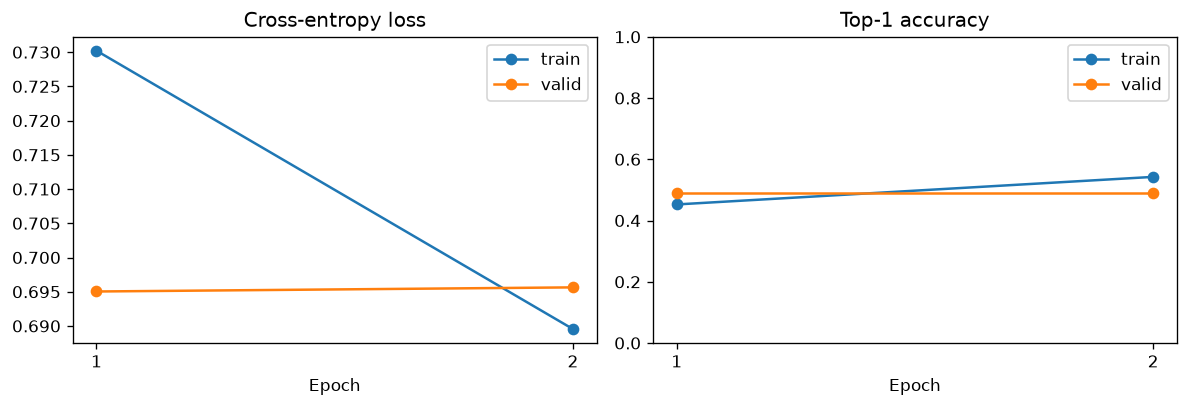

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for key, label in [('train_loss', 'train'), ('val_loss', 'valid')]:
    axes[0].plot([h['epoch'] for h in history], [h[key] for h in history], 'o-', label=label)
for key, label in [('train_acc', 'train'), ('val_acc', 'valid')]:
    axes[1].plot([h['epoch'] for h in history], [h[key] for h in history], 'o-', label=label)
for ax, title in zip(axes, ['Cross-entropy loss', 'Top-1 accuracy']):
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_xticks(range(1, EPOCHS + 1))
    ax.legend()
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()


## 8. 테스트 예측과 시각화 · 코드 6-88–6-89, p.338–340

마지막 epoch의 모델 대신 **검증 손실이 가장 낮았던 체크포인트**를 복원합니다.
softmax의 1번 열은 dog 확률입니다. 이 값은 예측 확률이며 실제 레이블이 아닙니다.
교재 시각화는 무작위로 고른 ID의 확률을 현재 이미지에 붙일 수 있으므로, 아래 코드는 같은 데이터 행의 이미지·확률·정답을 함께 유지합니다.


Best epoch=1 | Test loss=0.6750 | Top-1=70.00% | n=10
cat.145.jpg        true=0 p(dog)=0.4768 pred=0
dog.211.jpg        true=1 p(dog)=0.4747 pred=0
cat.162.jpg        true=0 p(dog)=0.4724 pred=0
cat.200.jpg        true=0 p(dog)=0.4746 pred=0
cat.210.jpg        true=0 p(dog)=0.4764 pred=0
cat.224.jpg        true=0 p(dog)=0.4740 pred=0
dog.213.jpg        true=1 p(dog)=0.4735 pred=0
cat.109.jpg        true=0 p(dog)=0.4741 pred=0
cat.15.jpg         true=0 p(dog)=0.4755 pred=0
dog.167.jpg        true=1 p(dog)=0.4730 pred=0
CSV: week1_results\ResNet_predictions.csv


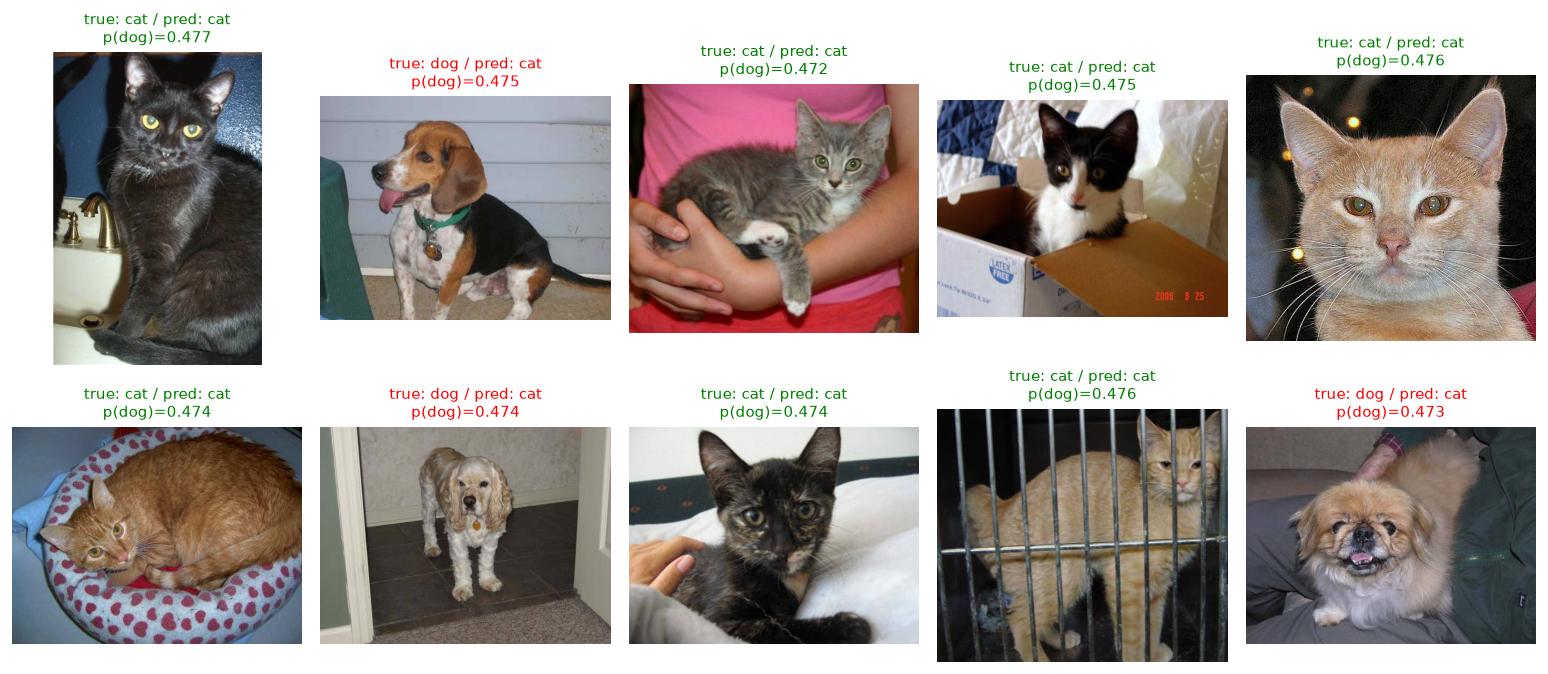

In [11]:
model.load_state_dict(torch.load(checkpoint, map_location=device, weights_only=True))
test_loss, test_acc = run_epoch(model, test_loader, criterion, device)
model.eval()
rows = []
with torch.no_grad():
    for index, (path, label) in enumerate(test_samples):
        image, _ = test_dataset[index]
        logits, _ = model(image.unsqueeze(0).to(device))
        p_dog = logits.softmax(dim=1)[0, 1].item()
        predicted = logits.argmax(1).item()
        rows.append(dict(file=str(path), true_label=label, p_dog=p_dog, predicted=predicted))
csv_path = OUTPUT_DIR / 'ResNet_predictions.csv'
with csv_path.open('w', encoding='utf-8', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=list(rows[0]))
    writer.writeheader()
    writer.writerows(rows)
print(f'Best epoch={best_epoch} | Test loss={test_loss:.4f} | Top-1={test_acc:.2%} | n={len(rows)}')
for row in rows:
    print(f"{Path(row['file']).name:18s} true={row['true_label']} p(dog)={row['p_dog']:.4f} pred={row['predicted']}")
print('CSV:', csv_path)
assert len(rows) == len(test_samples)
assert all(0 <= r['p_dog'] <= 1 for r in rows)

fig, axes = plt.subplots(2, 5, figsize=(13, 6))
names = {0: 'cat', 1: 'dog'}
for ax, row in zip(axes.flat, rows):
    with Image.open(row['file']) as im:
        ax.imshow(im.convert('RGB'))
    ax.set_title(f"true: {names[row['true_label']]} / pred: {names[row['predicted']]}\np(dog)={row['p_dog']:.3f}",
                 color='green' if row['true_label'] == row['predicted'] else 'red', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()


## 실행 결과 해석

| Epoch | Train loss | Train top-1 | Valid loss | Valid top-1 |
|---|---:|---:|---:|---:|
| 1 | 0.7302 | 45.25% | 0.6950 | 48.91% |
| 2 | 0.6895 | 54.25% | 0.6956 | 48.91% |

검증 손실이 더 낮은 **1 epoch**의 모델을 복원했다. 테스트 손실은 **0.6750**, top-1 정확도는 **70% (7/10)**였다.
그러나 예측 10개가 모두 고양이였고, 테스트셋도 고양이 7장·개 3장이었다.
따라서 이 70%는 **항상 고양이라고 예측하는 기준선과 동일**하며, 개와 고양이를 잘 구별했다고 해석할 수 없다.
검증 정확도 48.91% 역시 검증셋 고양이 비율 45/92와 같다.
훈련 손실 감소만으로 일반화 성능이 개선됐다고 결론 내리지 않고, 검증 손실과 클래스별 예측을 함께 확인해야 한다.
이 결과는 저장된 실제 실행 출력에 대한 해석이며 교재의 224×224·10 epochs 실험을 재현한 수치가 아니다.


## 9. 코드 리뷰 결론

1. **잔차 연결:** `F(x)+x`를 더할 때 크기가 같아야 한다. 채널 변화뿐 아니라 stride 변화도 shortcut 투영 조건에 포함했다.
2. **모델 구분:** 직접 구현한 ResNet50과 사전학습 ResNet50은 구별해야 한다. 구조를 정의했다고 사전학습 가중치가 자동 적용되지는 않는다.
3. **정확도 해석:** 이진 분류의 top-2=100%는 좋은 분류기의 증거가 아니다. top-1과 검증 손실을 함께 확인한다.
4. **평가 신뢰성:** 검증·테스트에는 무작위 증강을 적용하지 않고, `eval()`과 기울기 비활성화를 사용한다. 테스트 전에 최적 가중치를 복원한다.
5. **출력 대응:** 이미지와 예측을 같은 행으로 유지해야 한다. 확률만 임의로 선택하면 잘못된 시각화가 된다.
6. **실험 한계:** 64×64, 2 epochs, 작은 데이터, 무작위 초기화, 1e-7 학습률은 높은 정확도를 검증하는 설정이 아니다. 테스트 10개에서는 이미지 한 장이 정확도를 10%p 바꾼다. 성능 개선 실험은 학습률·사전학습·데이터 규모를 검증셋으로 비교하고 테스트셋은 최종 평가에만 사용해야 한다.

### 참고 자료

- 제공된 『딥러닝 파이토치 교과서』 PDF, 6.1.5절 인쇄 p.312–340. 구현 순서와 리뷰의 주된 자료.
- [길벗 공식 예제·데이터](https://github.com/gilbutITbook/080289), chap06/data/dogs-vs-cats.zip.
- [TorchVision 공식 모델 API](https://docs.pytorch.org/vision/stable/models): `pretrained=True` 대신 `weights` 인자를 사용하는 방법 참고.

### 다시 실행하기

Colab에서 위에서부터 모두 실행합니다. 첫 실행에는 공개 교재 데이터를 내려받을 인터넷 연결이 필요합니다.
교재 크기로 실습하려면 첫 설정 셀에서 `FULL_RUN=True`로 변경하고 GPU 런타임에서 전체 실행합니다.
실행 후 `.ipynb`를 다운로드하면 코드·주석·출력 그래프가 함께 보존됩니다.
